In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

PALETTE = '#2563EB'
ACCENT  = '#DC2626'
GREEN   = '#16A34A'

print('Imports done')

Imports done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = '/your_path'

df = pd.read_csv(CSV_PATH, parse_dates=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

print(f'Rows     : {len(df):,}')
print(f'Columns  : {df.shape[1]}')
print(f'From     : {df.Datetime.min()}')
print(f'To       : {df.Datetime.max()}')
print(f'Missing  : {df.isnull().sum().sum()} values')

Mounted at /content/drive
Rows     : 134,715
Columns  : 15
From     : 2010-01-05 02:00:00
To       : 2025-12-31 23:00:00
Missing  : 0 values


In [3]:
sources = {
    'Temperature_C':        'NASA POWER',
    'Relative_Humidity':    'NASA POWER',
    'Surface_Pressure_kPa': 'NASA POWER',
    'Precipitation_mm':     'NASA POWER  ← TARGET',
    'ZTD':                  'NGL GNSS',
    'PWV':                  'NGL GNSS',
    'hour_sin':             'Feature Engineering',
    'hour_cos':             'Feature Engineering',
    'month_sin':            'Feature Engineering',
    'month_cos':            'Feature Engineering',
    'Precipitation_Lag1':   'Feature Engineering',
    'Precipitation_Lag3':   'Feature Engineering',
    'Precipitation_Lag6':   'Feature Engineering',
    'Precipitation_Lag24':  'Feature Engineering',
}
inv = pd.DataFrame({'Column': list(sources.keys()),
                    'Source': list(sources.values())})
inv.index = range(1, len(inv)+1)
print(inv.to_string())

                  Column                Source
1          Temperature_C            NASA POWER
2      Relative_Humidity            NASA POWER
3   Surface_Pressure_kPa            NASA POWER
4       Precipitation_mm  NASA POWER  ← TARGET
5                    ZTD              NGL GNSS
6                    PWV              NGL GNSS
7               hour_sin   Feature Engineering
8               hour_cos   Feature Engineering
9              month_sin   Feature Engineering
10             month_cos   Feature Engineering
11    Precipitation_Lag1   Feature Engineering
12    Precipitation_Lag3   Feature Engineering
13    Precipitation_Lag6   Feature Engineering
14   Precipitation_Lag24   Feature Engineering


In [4]:
phys_cols = ['Temperature_C', 'Relative_Humidity', 'Surface_Pressure_kPa',
             'Precipitation_mm', 'ZTD', 'PWV']
df[phys_cols].describe().round(3)

,Temperature_C,Relative_Humidity,Surface_Pressure_kPa,Precipitation_mm,ZTD,PWV
count,134715.000,134715.000,134715.000,134715.000,134715.000,134715.000
mean,23.911,67.852,91.674,0.098,2270.336,32.524
std,5.185,25.446,0.265,0.387,71.554,12.100
min,9.220,3.270,90.120,0.000,2087.650,3.310
25%,20.240,48.750,91.480,0.000,2208.958,22.107
50%,23.140,72.010,91.660,0.000,2286.333,35.396
75%,27.440,91.900,91.860,0.035,2332.092,42.963
max,40.780,100.000,92.630,30.611,2418.175,57.857


Zero-rain hours  : 65,207  (48.4%)
Rainy hours      : 69,508  (51.6%)
Max precip       : 30.61 mm/hr
Mean (non-zero)  : 0.190 mm/hr
P90              : 0.242 mm/hr
P99              : 1.601 mm/hr
P99.9            : 3.782 mm/hr


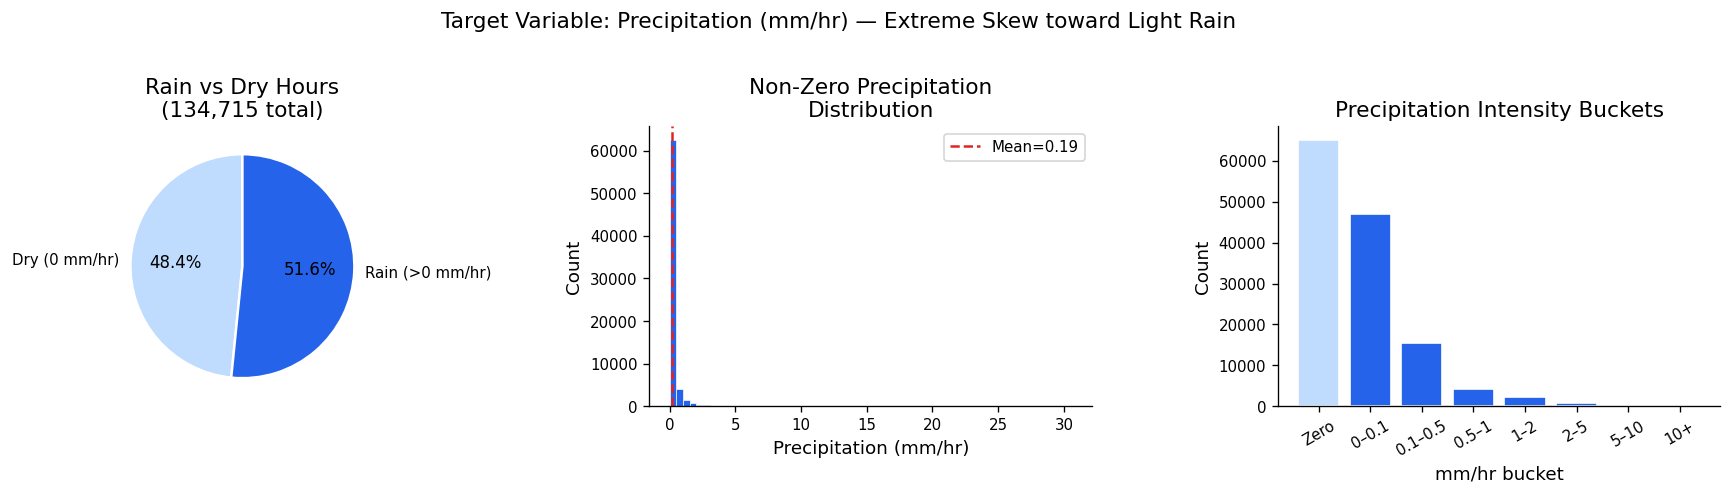

In [5]:
rain      = df['Precipitation_mm']
n_zero    = (rain == 0).sum()
n_nonzero = (rain  > 0).sum()
pct_zero  = n_zero / len(rain) * 100

print(f'Zero-rain hours  : {n_zero:,}  ({pct_zero:.1f}%)')
print(f'Rainy hours      : {n_nonzero:,}  ({100-pct_zero:.1f}%)')
print(f'Max precip       : {rain.max():.2f} mm/hr')
print(f'Mean (non-zero)  : {rain[rain>0].mean():.3f} mm/hr')
print(f'P90              : {rain.quantile(0.90):.3f} mm/hr')
print(f'P99              : {rain.quantile(0.99):.3f} mm/hr')
print(f'P99.9            : {rain.quantile(0.999):.3f} mm/hr')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pie chart
axes[0].pie([n_zero, n_nonzero],
            labels=['Dry (0 mm/hr)', 'Rain (>0 mm/hr)'],
            colors=['#BFDBFE', PALETTE],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Rain vs Dry Hours\n(134,715 total)')

# Histogram
nz = rain[rain > 0]
axes[1].hist(nz, bins=60, color=PALETTE, edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Precipitation (mm/hr)')
axes[1].set_ylabel('Count')
axes[1].set_title('Non-Zero Precipitation\nDistribution')
axes[1].axvline(nz.mean(), color=ACCENT, linestyle='--',
                label=f'Mean={nz.mean():.2f}')
axes[1].legend()

# Intensity buckets
buckets = {
    'Zero':    (rain == 0).sum(),
    '0–0.1':   ((rain > 0)   & (rain <= 0.1)).sum(),
    '0.1–0.5': ((rain > 0.1) & (rain <= 0.5)).sum(),
    '0.5–1':   ((rain > 0.5) & (rain <= 1.0)).sum(),
    '1–2':     ((rain > 1.0) & (rain <= 2.0)).sum(),
    '2–5':     ((rain > 2.0) & (rain <= 5.0)).sum(),
    '5–10':    ((rain > 5.0) & (rain <= 10.0)).sum(),
    '10+':     (rain > 10.0).sum(),
}
axes[2].bar(buckets.keys(), buckets.values(),
            color=[PALETTE if k != 'Zero' else '#BFDBFE' for k in buckets],
            edgecolor='white')
axes[2].set_xlabel('mm/hr bucket')
axes[2].set_ylabel('Count')
axes[2].set_title('Precipitation Intensity Buckets')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Target Variable: Precipitation (mm/hr) — Extreme Skew toward Light Rain',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

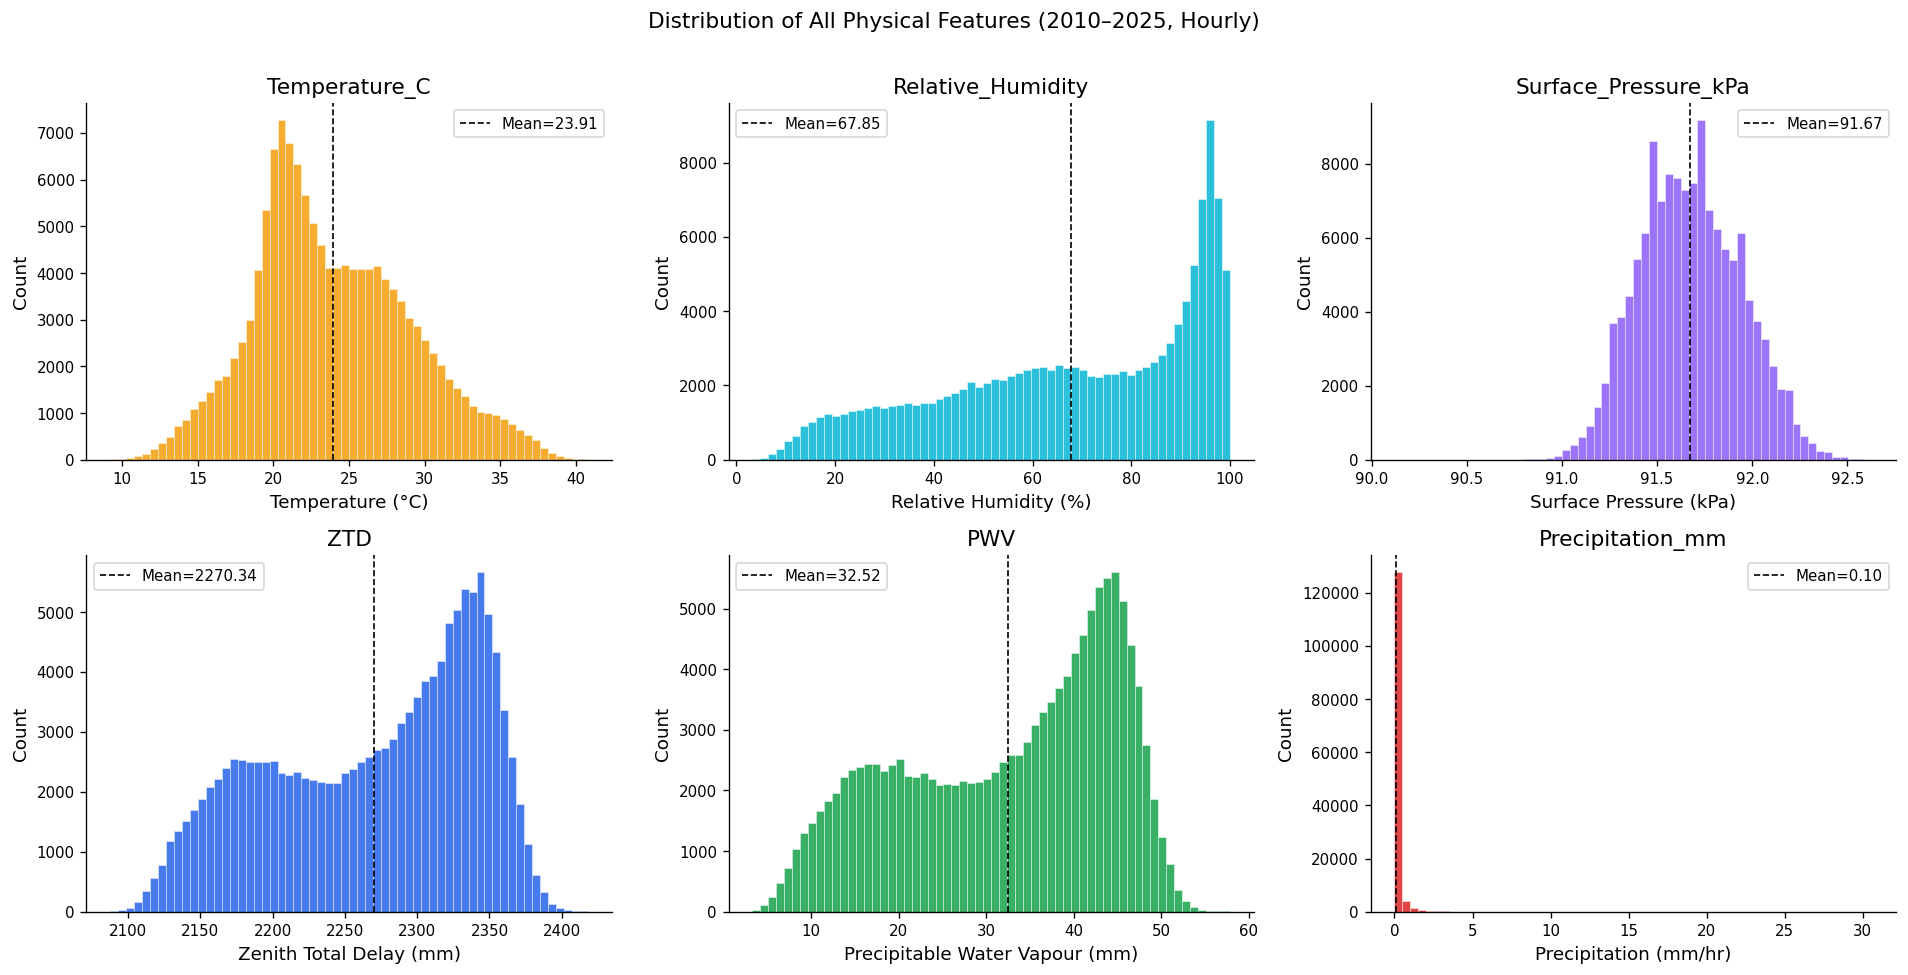

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
configs = [
    ('Temperature_C',        'Temperature (°C)',           '#F59E0B'),
    ('Relative_Humidity',    'Relative Humidity (%)',      '#06B6D4'),
    ('Surface_Pressure_kPa', 'Surface Pressure (kPa)',     '#8B5CF6'),
    ('ZTD',                  'Zenith Total Delay (mm)',    PALETTE),
    ('PWV',                  'Precipitable Water Vapour (mm)', GREEN),
    ('Precipitation_mm',     'Precipitation (mm/hr)',      ACCENT),
]
for ax, (col, label, color) in zip(axes.flat, configs):
    data = df[col]
    ax.hist(data, bins=60, color=color, edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1,
               label=f'Mean={data.mean():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(col)
    ax.legend()

plt.suptitle('Distribution of All Physical Features (2010–2025, Hourly)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

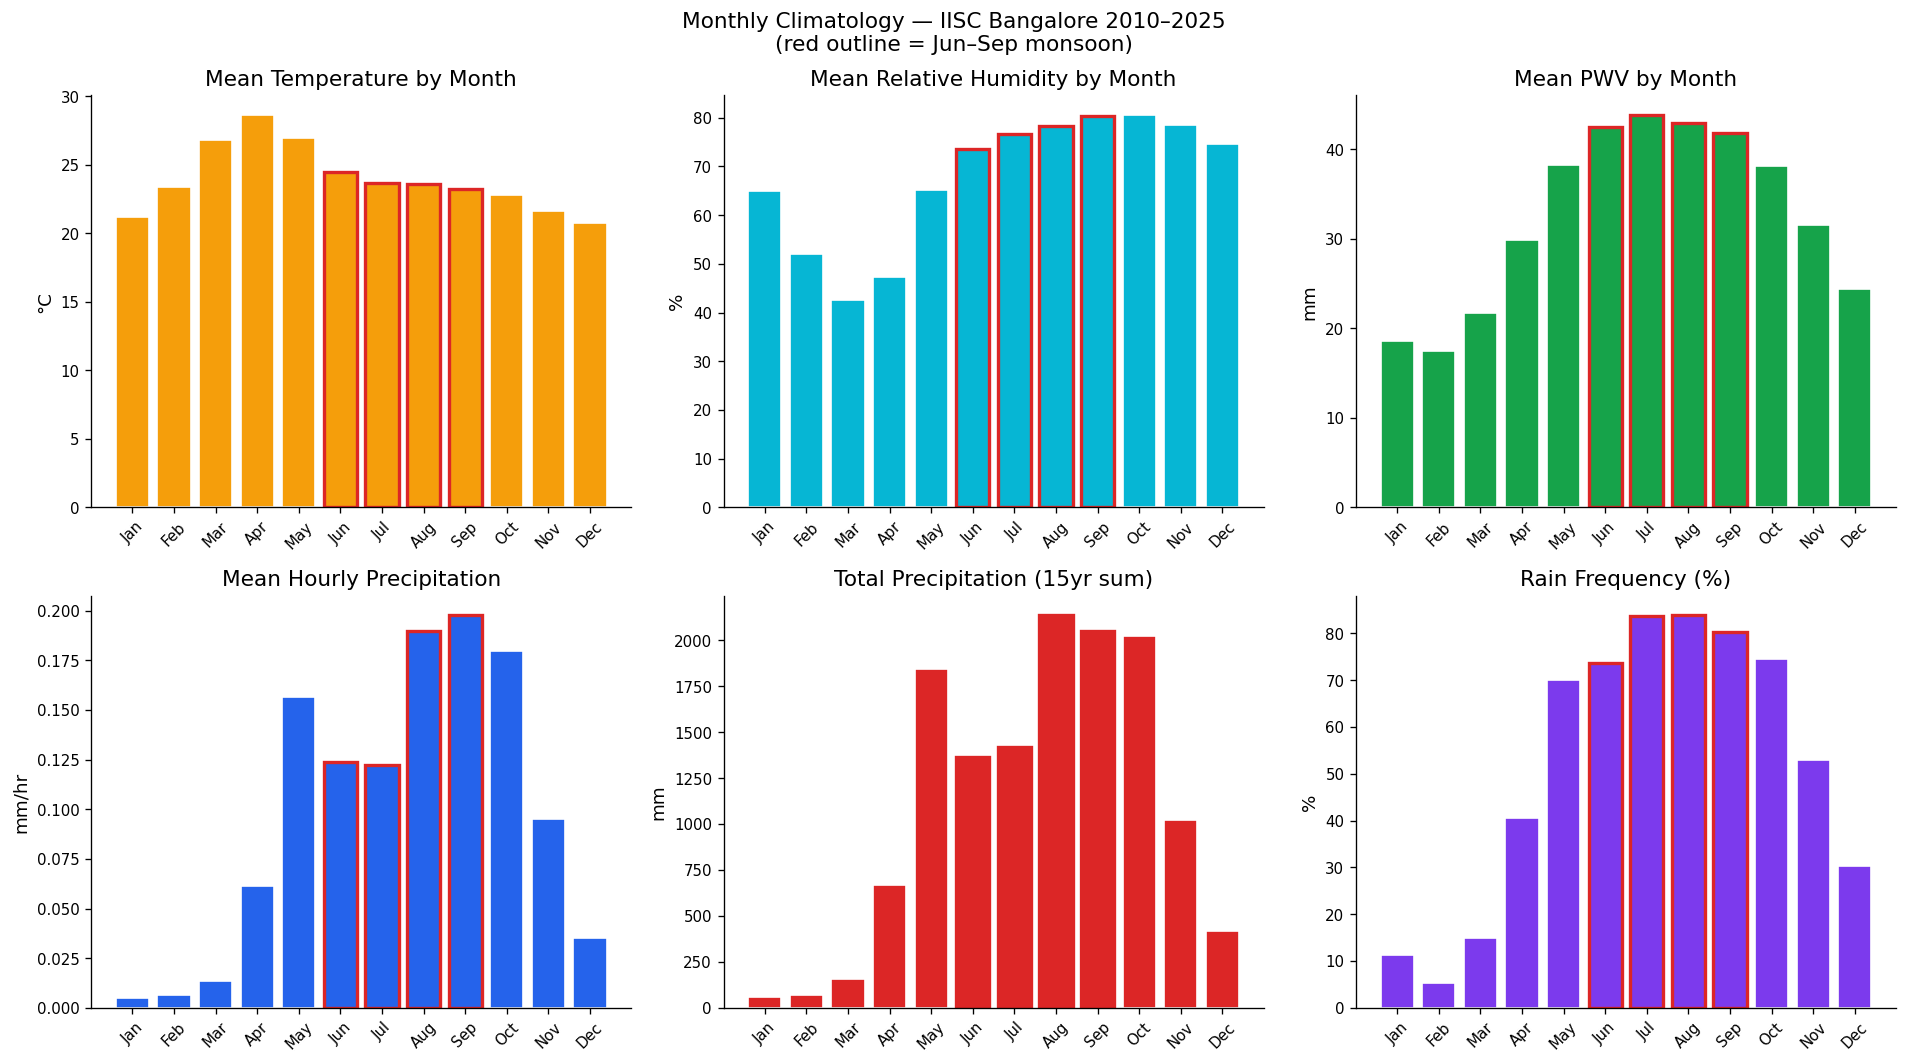

In [7]:
df['month'] = df['Datetime'].dt.month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = df.groupby('month').agg(
    Temp        =('Temperature_C',    'mean'),
    RH          =('Relative_Humidity','mean'),
    PWV_mean    =('PWV',              'mean'),
    Precip_mean =('Precipitation_mm', 'mean'),
    Precip_sum  =('Precipitation_mm', 'sum'),
    Rain_freq   =('Precipitation_mm', lambda x: (x > 0).mean() * 100)
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

def month_bar(ax, values, title, ylabel, color):
    bars = ax.bar(month_labels, values, color=color, edgecolor='white')
    for i in range(5, 9):
        bars[i].set_edgecolor(ACCENT)
        bars[i].set_linewidth(2)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)

month_bar(axes[0,0], monthly['Temp'],        'Mean Temperature by Month',       '°C',    '#F59E0B')
month_bar(axes[0,1], monthly['RH'],          'Mean Relative Humidity by Month', '%',     '#06B6D4')
month_bar(axes[0,2], monthly['PWV_mean'],    'Mean PWV by Month',               'mm',    GREEN)
month_bar(axes[1,0], monthly['Precip_mean'], 'Mean Hourly Precipitation',       'mm/hr', PALETTE)
month_bar(axes[1,1], monthly['Precip_sum'],  'Total Precipitation (15yr sum)',  'mm',    ACCENT)
month_bar(axes[1,2], monthly['Rain_freq'],   'Rain Frequency (%)',              '%',     '#7C3AED')

plt.suptitle('Monthly Climatology — IISC Bangalore 2010–2025\n(red outline = Jun–Sep monsoon)',
             fontsize=13)
plt.tight_layout()
plt.show()

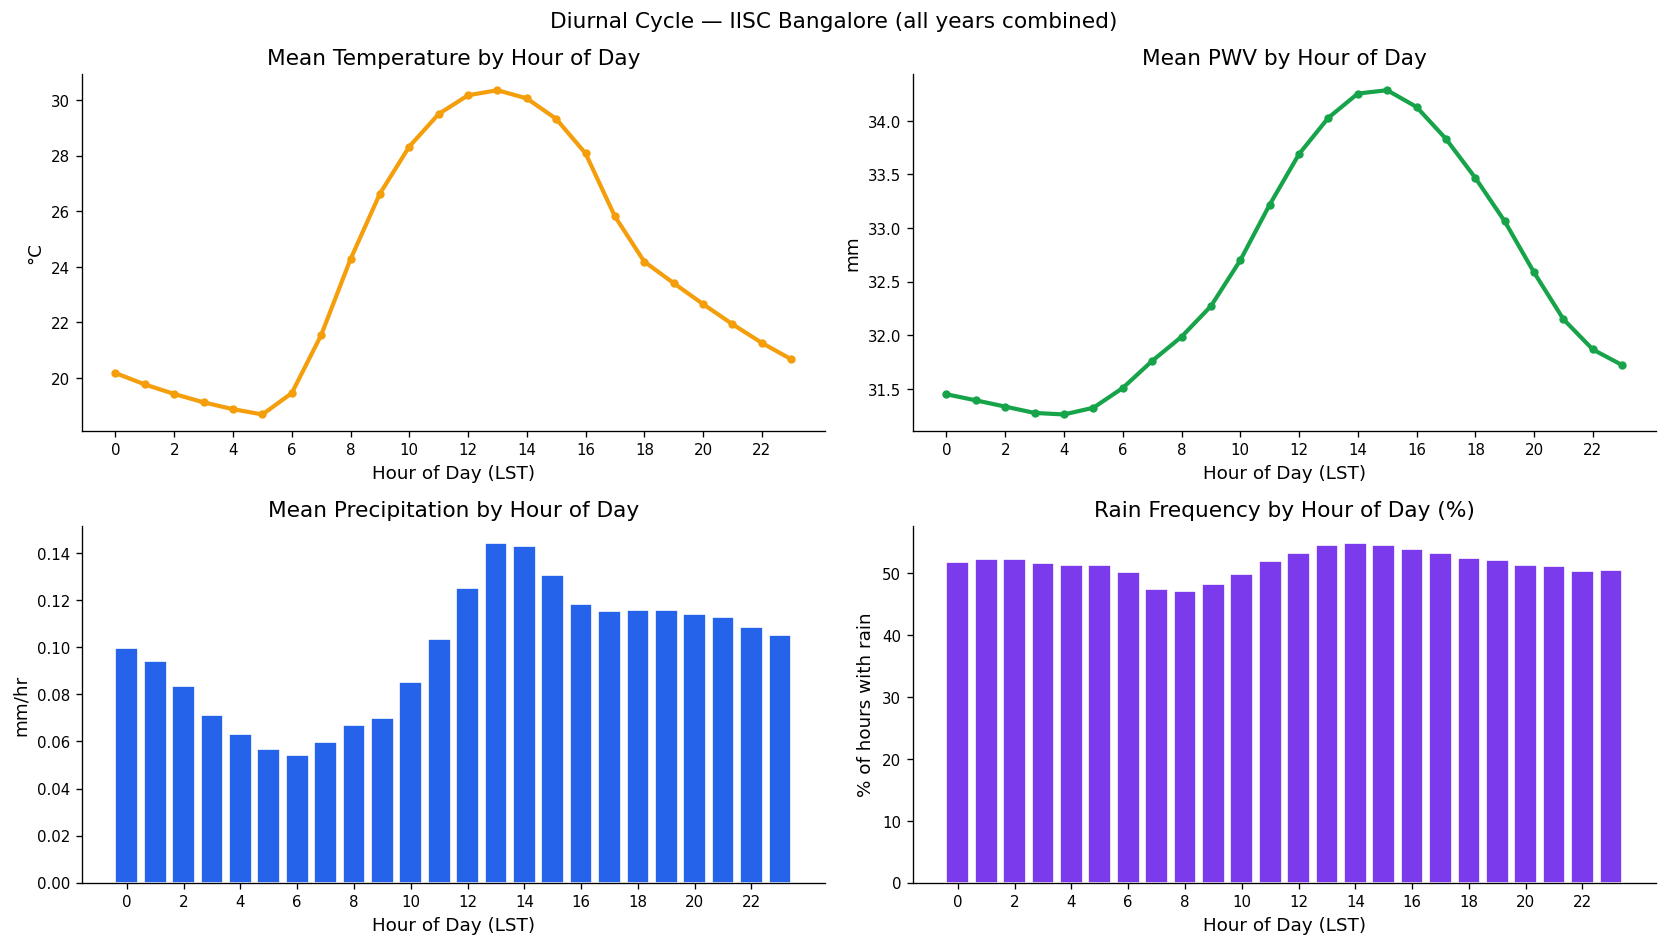

In [8]:
df['hour'] = df['Datetime'].dt.hour

hourly = df.groupby('hour').agg(
    Temp      =('Temperature_C',    'mean'),
    PWV       =('PWV',              'mean'),
    Precip    =('Precipitation_mm', 'mean'),
    Rain_freq =('Precipitation_mm', lambda x: (x > 0).mean() * 100)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
hrs = hourly.index

axes[0,0].plot(hrs, hourly['Temp'], color='#F59E0B', linewidth=2.5, marker='o', ms=4)
axes[0,0].set_title('Mean Temperature by Hour of Day')
axes[0,0].set_ylabel('°C')

axes[0,1].plot(hrs, hourly['PWV'], color=GREEN, linewidth=2.5, marker='o', ms=4)
axes[0,1].set_title('Mean PWV by Hour of Day')
axes[0,1].set_ylabel('mm')

axes[1,0].bar(hrs, hourly['Precip'], color=PALETTE, edgecolor='white')
axes[1,0].set_title('Mean Precipitation by Hour of Day')
axes[1,0].set_ylabel('mm/hr')

axes[1,1].bar(hrs, hourly['Rain_freq'], color='#7C3AED', edgecolor='white')
axes[1,1].set_title('Rain Frequency by Hour of Day (%)')
axes[1,1].set_ylabel('% of hours with rain')

for ax in axes.flat:
    ax.set_xlabel('Hour of Day (LST)')
    ax.set_xticks(range(0, 24, 2))

plt.suptitle('Diurnal Cycle — IISC Bangalore (all years combined)', fontsize=13)
plt.tight_layout()
plt.show()

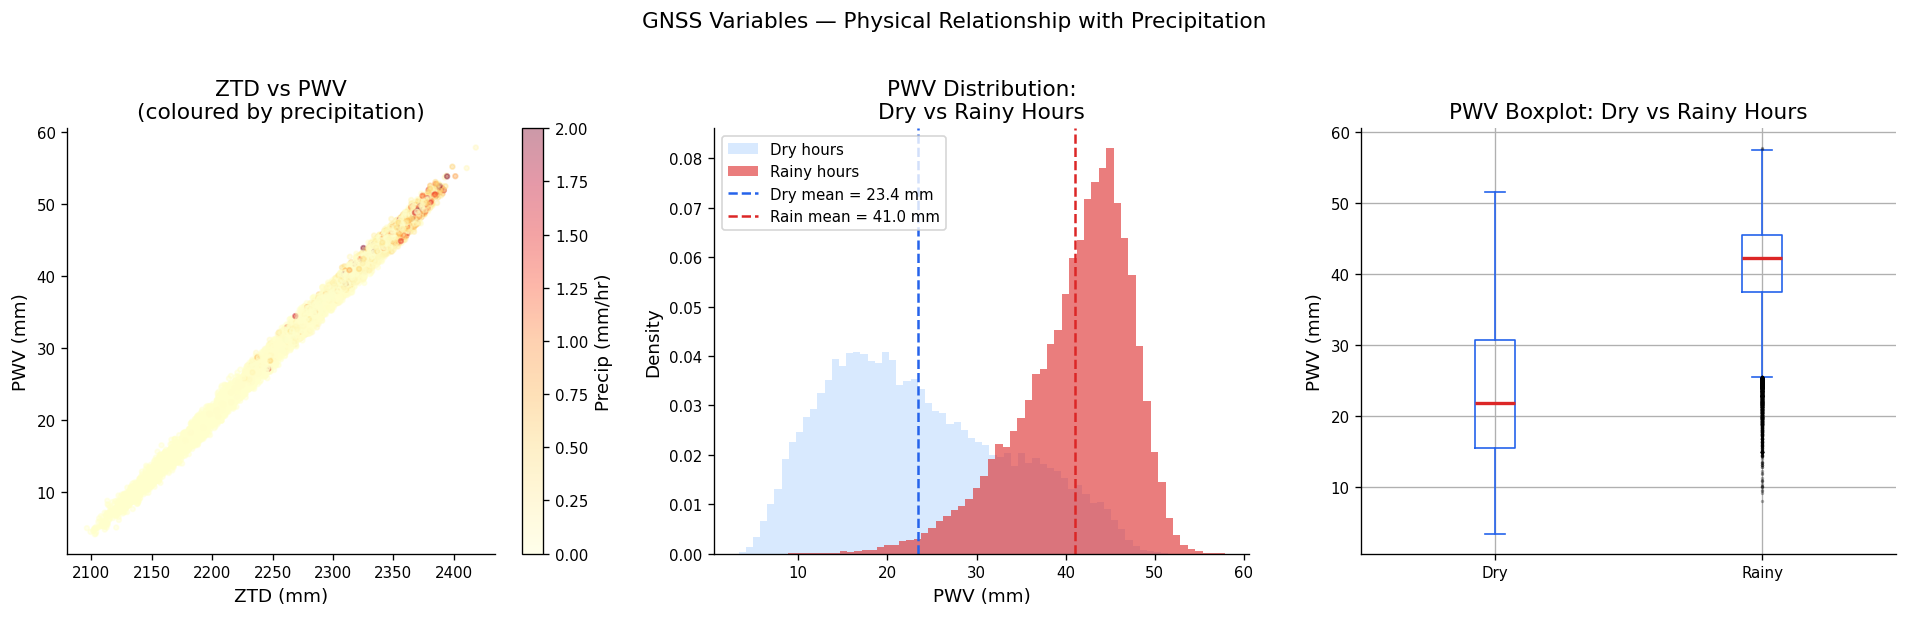

Mean PWV (dry hours)   : 23.44 mm
Mean PWV (rainy hours) : 41.04 mm
Difference             : 17.60 mm


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter ZTD vs PWV coloured by precipitation
sample = df.sample(10000, random_state=42)
sc = axes[0].scatter(sample['ZTD'], sample['PWV'],
                     c=sample['Precipitation_mm'],
                     cmap='YlOrRd', alpha=0.4, s=8, vmin=0, vmax=2)
plt.colorbar(sc, ax=axes[0], label='Precip (mm/hr)')
axes[0].set_xlabel('ZTD (mm)')
axes[0].set_ylabel('PWV (mm)')
axes[0].set_title('ZTD vs PWV\n(coloured by precipitation)')

# PWV distribution dry vs rainy
dry_pwv  = df.loc[df['Precipitation_mm'] == 0, 'PWV']
rain_pwv = df.loc[df['Precipitation_mm']  > 0, 'PWV']
axes[1].hist(dry_pwv,  bins=60, alpha=0.6, color='#BFDBFE',
             label='Dry hours',   density=True)
axes[1].hist(rain_pwv, bins=60, alpha=0.6, color=ACCENT,
             label='Rainy hours', density=True)
axes[1].axvline(dry_pwv.mean(),  color=PALETTE, linestyle='--', linewidth=1.5,
                label=f'Dry mean = {dry_pwv.mean():.1f} mm')
axes[1].axvline(rain_pwv.mean(), color=ACCENT,  linestyle='--', linewidth=1.5,
                label=f'Rain mean = {rain_pwv.mean():.1f} mm')
axes[1].set_xlabel('PWV (mm)')
axes[1].set_ylabel('Density')
axes[1].set_title('PWV Distribution:\nDry vs Rainy Hours')
axes[1].legend()

# Boxplot
df['Rain_Flag'] = df['Precipitation_mm'].apply(lambda x: 'Rainy' if x > 0 else 'Dry')
df.boxplot(column='PWV', by='Rain_Flag', ax=axes[2],
           boxprops=dict(color=PALETTE),
           medianprops=dict(color=ACCENT, linewidth=2),
           whiskerprops=dict(color=PALETTE),
           capprops=dict(color=PALETTE),
           flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[2].set_title('PWV Boxplot: Dry vs Rainy Hours')
axes[2].set_xlabel('')
axes[2].set_ylabel('PWV (mm)')
plt.suptitle('')

plt.suptitle('GNSS Variables — Physical Relationship with Precipitation',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean PWV (dry hours)   : {dry_pwv.mean():.2f} mm')
print(f'Mean PWV (rainy hours) : {rain_pwv.mean():.2f} mm')
print(f'Difference             : {rain_pwv.mean() - dry_pwv.mean():.2f} mm')

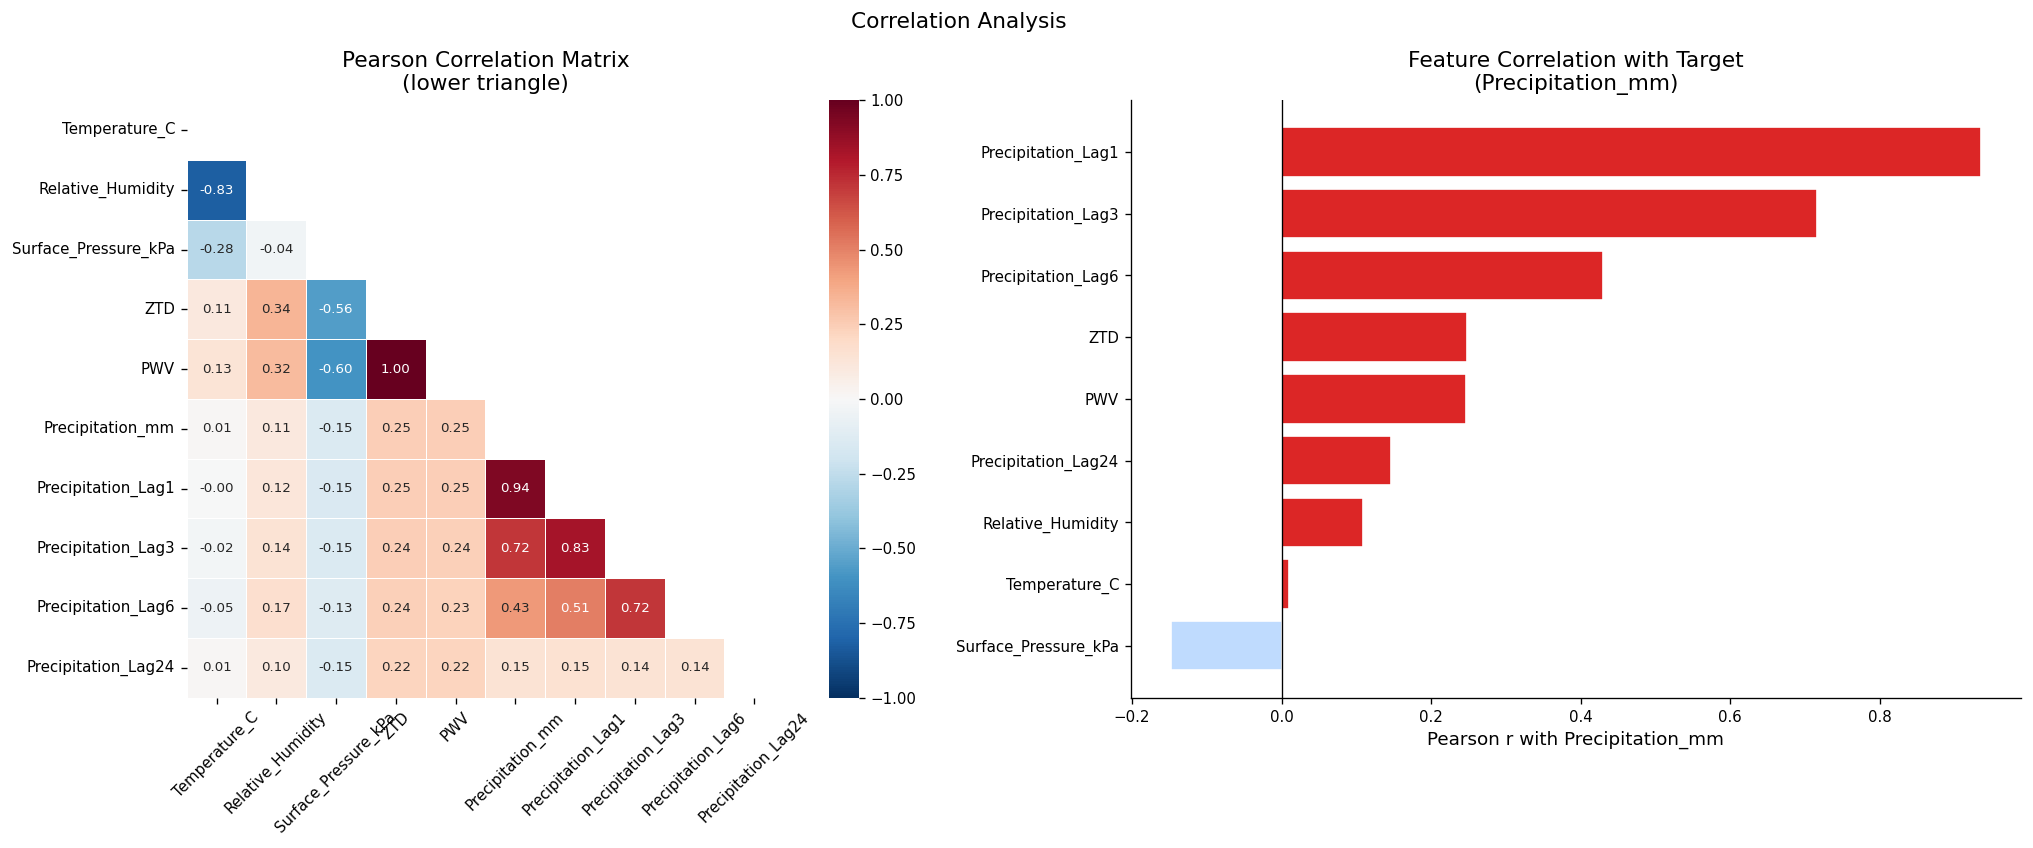

In [10]:
corr_cols = ['Temperature_C', 'Relative_Humidity', 'Surface_Pressure_kPa',
             'ZTD', 'PWV', 'Precipitation_mm',
             'Precipitation_Lag1', 'Precipitation_Lag3',
             'Precipitation_Lag6', 'Precipitation_Lag24']

corr = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0],
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, square=True)
axes[0].set_title('Pearson Correlation Matrix\n(lower triangle)')
axes[0].tick_params(axis='x', rotation=45)

target_corr = corr['Precipitation_mm'].drop('Precipitation_mm').sort_values()
colors = [ACCENT if v > 0 else '#BFDBFE' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson r with Precipitation_mm')
axes[1].set_title('Feature Correlation with Target\n(Precipitation_mm)')

plt.suptitle('Correlation Analysis', fontsize=13)
plt.tight_layout()
plt.show()

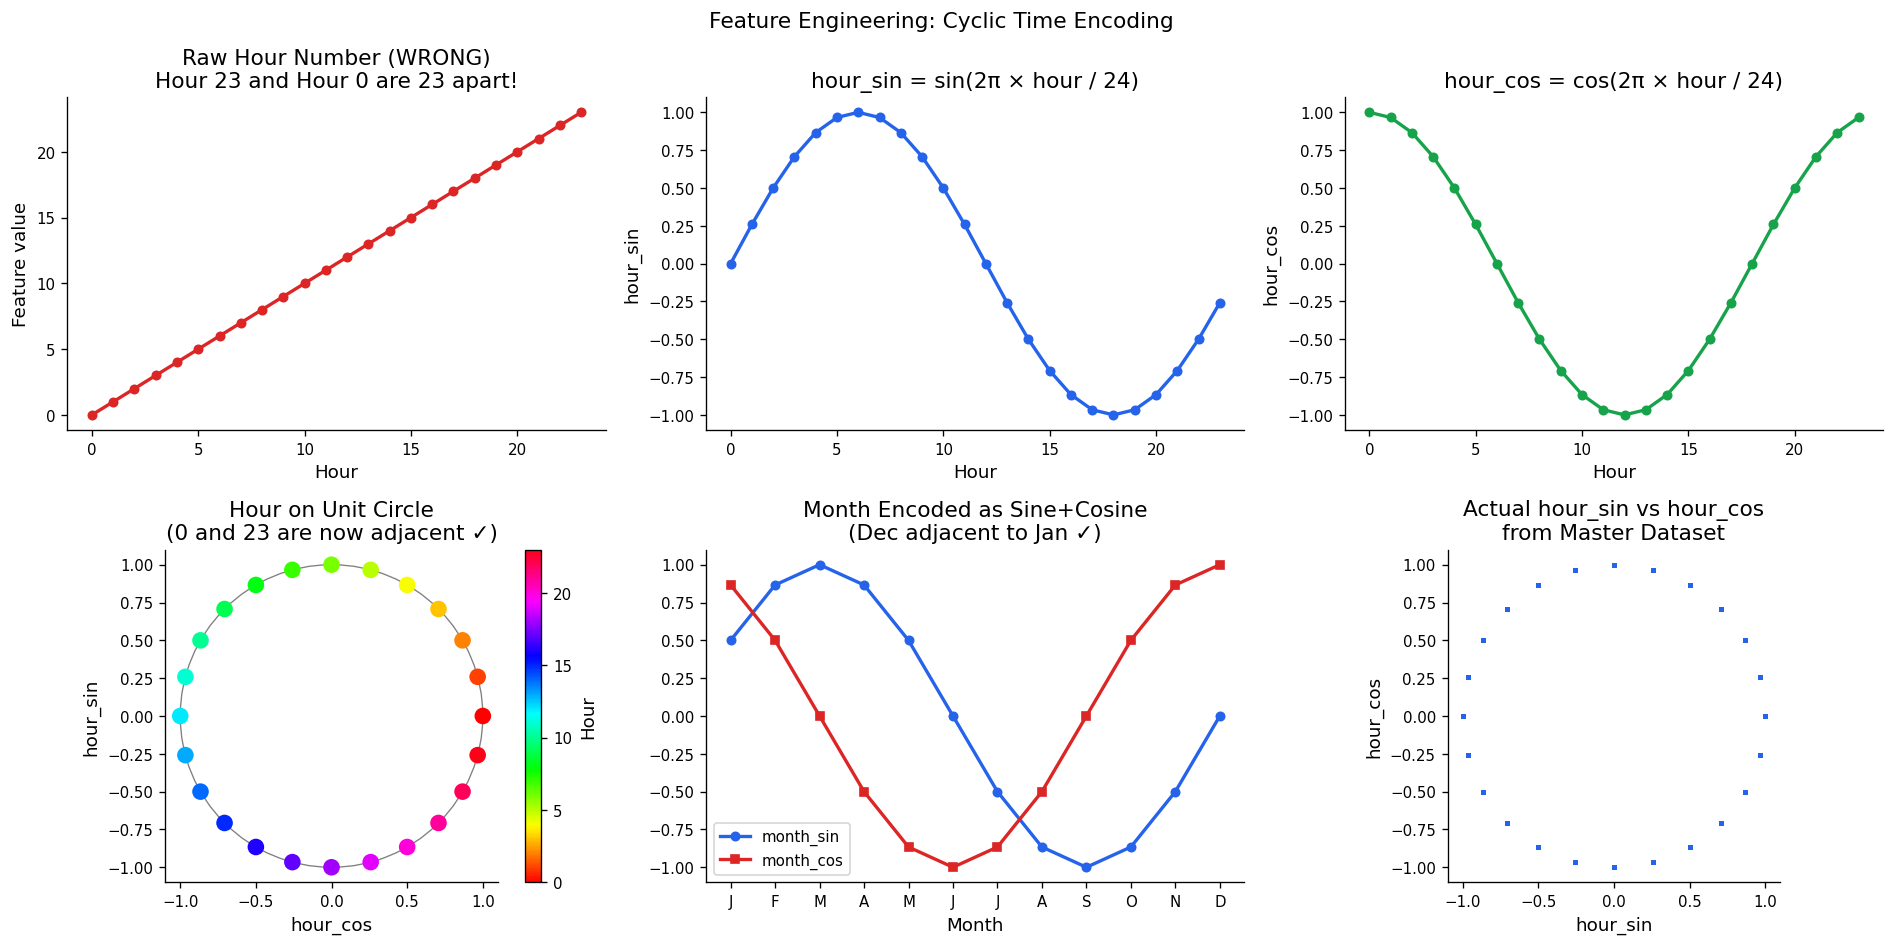

In [11]:
hours  = np.arange(24)
months = np.arange(1, 13)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Raw hour (problem)
axes[0,0].plot(hours, hours, color=ACCENT, linewidth=2, marker='o', ms=5)
axes[0,0].set_title('Raw Hour Number (WRONG)\nHour 23 and Hour 0 are 23 apart!')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Feature value')

# Sine
axes[0,1].plot(hours, np.sin(2*np.pi*hours/24),
               color=PALETTE, linewidth=2, marker='o', ms=5)
axes[0,1].set_title('hour_sin = sin(2π × hour / 24)')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('hour_sin')

# Cosine
axes[0,2].plot(hours, np.cos(2*np.pi*hours/24),
               color=GREEN, linewidth=2, marker='o', ms=5)
axes[0,2].set_title('hour_cos = cos(2π × hour / 24)')
axes[0,2].set_xlabel('Hour')
axes[0,2].set_ylabel('hour_cos')

# Unit circle
hs = np.sin(2*np.pi*hours/24)
hc = np.cos(2*np.pi*hours/24)
sc = axes[1,0].scatter(hc, hs, c=hours, cmap='hsv', s=80, zorder=3)
plt.colorbar(sc, ax=axes[1,0], label='Hour')
axes[1,0].set_aspect('equal')
axes[1,0].add_patch(plt.Circle((0,0), 1, fill=False, color='grey', linewidth=0.8))
axes[1,0].set_title('Hour on Unit Circle\n(0 and 23 are now adjacent ✓)')
axes[1,0].set_xlabel('hour_cos')
axes[1,0].set_ylabel('hour_sin')

# Month sin+cos
axes[1,1].plot(months, np.sin(2*np.pi*months/12),
               color=PALETTE, linewidth=2, marker='o', ms=5, label='month_sin')
axes[1,1].plot(months, np.cos(2*np.pi*months/12),
               color=ACCENT, linewidth=2, marker='s', ms=5, label='month_cos')
axes[1,1].set_xticks(months)
axes[1,1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1,1].set_title('Month Encoded as Sine+Cosine\n(Dec adjacent to Jan ✓)')
axes[1,1].set_xlabel('Month')
axes[1,1].legend()

# Actual data unit circle
axes[1,2].scatter(df['hour_sin'].sample(5000, random_state=0),
                  df['hour_cos'].sample(5000, random_state=0),
                  alpha=0.15, s=4, color=PALETTE)
axes[1,2].set_aspect('equal')
axes[1,2].set_title('Actual hour_sin vs hour_cos\nfrom Master Dataset')
axes[1,2].set_xlabel('hour_sin')
axes[1,2].set_ylabel('hour_cos')

plt.suptitle('Feature Engineering: Cyclic Time Encoding', fontsize=13)
plt.tight_layout()
plt.show()

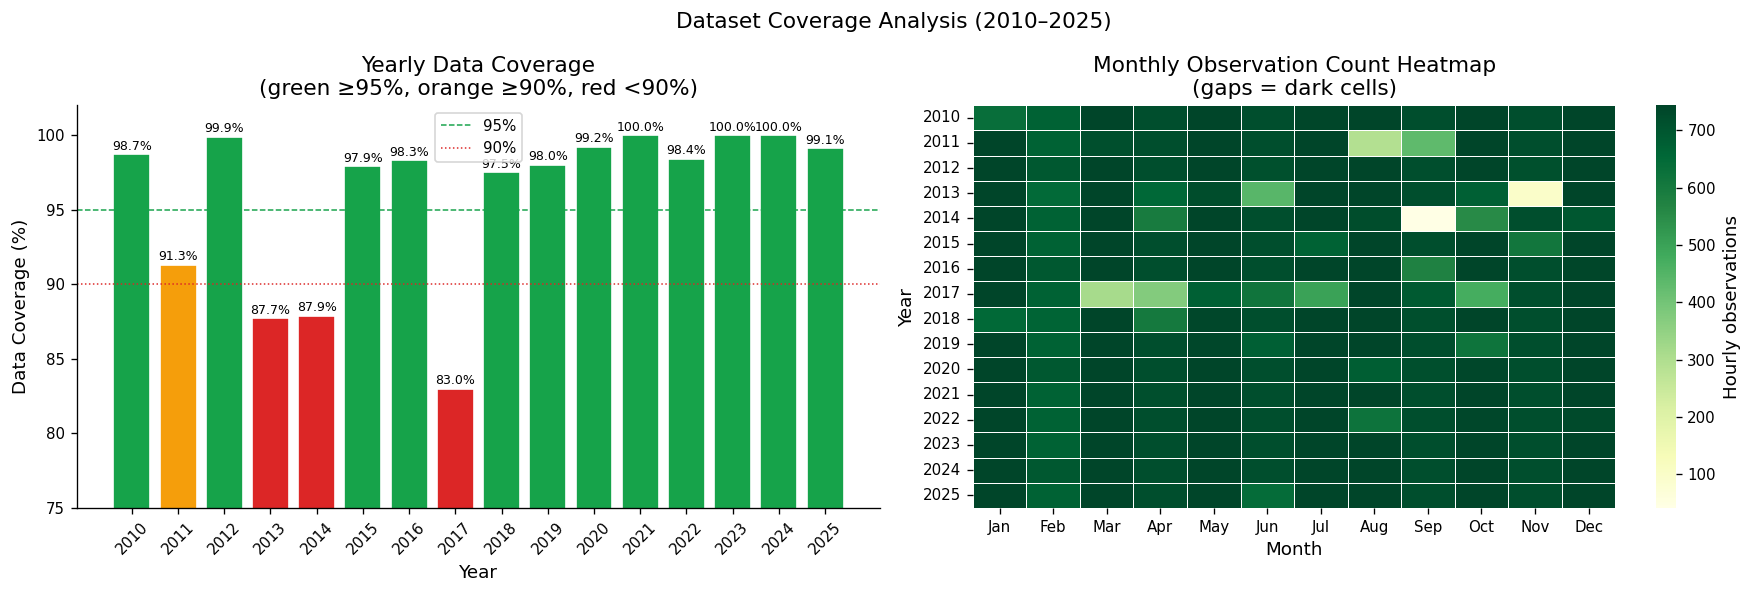

      Expected  Actual  Coverage_%
2010      8760    8649        98.7
2011      8760    7994        91.3
2012      8784    8775        99.9
2013      8760    7683        87.7
2014      8760    7696        87.9
2015      8760    8576        97.9
2016      8784    8636        98.3
2017      8760    7272        83.0
2018      8760    8537        97.5
2019      8760    8584        98.0
2020      8784    8711        99.2
2021      8760    8759       100.0
2022      8760    8616        98.4
2023      8760    8760       100.0
2024      8784    8784       100.0
2025      8760    8683        99.1

Overall coverage: 96.0%


In [12]:
df['year'] = df['Datetime'].dt.year

expected = {yr: (366 if yr in [2012,2016,2020,2024] else 365)*24
            for yr in range(2010, 2026)}
actual   = df.groupby('year').size()
coverage = pd.DataFrame({'Expected': pd.Series(expected), 'Actual': actual})
coverage['Coverage_%'] = (coverage['Actual'] / coverage['Expected'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bar_colors = [GREEN if c >= 95 else '#F59E0B' if c >= 90 else ACCENT
              for c in coverage['Coverage_%']]
axes[0].bar(coverage.index, coverage['Coverage_%'],
            color=bar_colors, edgecolor='white')
axes[0].axhline(95, color=GREEN,  linestyle='--', linewidth=0.9, label='95%')
axes[0].axhline(90, color=ACCENT, linestyle=':',  linewidth=0.9, label='90%')
axes[0].set_ylim(75, 102)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Data Coverage (%)')
axes[0].set_title('Yearly Data Coverage\n(green ≥95%, orange ≥90%, red <90%)')
axes[0].set_xticks(coverage.index)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
for yr, val in zip(coverage.index, coverage['Coverage_%']):
    axes[0].text(yr, val + 0.3, f'{val}%', ha='center', fontsize=7.5)

monthly_counts = df.groupby(['year','month']).size().unstack(fill_value=0)
sns.heatmap(monthly_counts, ax=axes[1], cmap='YlGn',
            linewidths=0.3, cbar_kws={'label': 'Hourly observations'},
            xticklabels=['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].set_title('Monthly Observation Count Heatmap\n(gaps = dark cells)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Year')

plt.suptitle('Dataset Coverage Analysis (2010–2025)', fontsize=13)
plt.tight_layout()
plt.show()

print(coverage.to_string())
print(f'\nOverall coverage: {actual.sum()/sum(expected.values())*100:.1f}%')

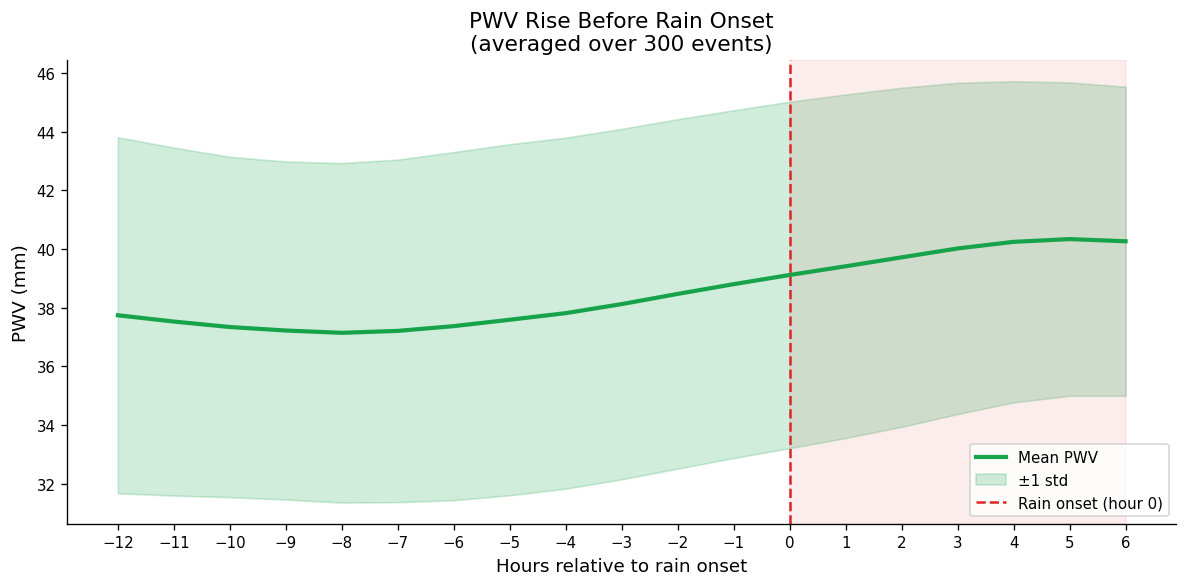

Mean PWV 12 hr before rain : 37.74 mm
Mean PWV at rain onset     : 39.12 mm
Rise before onset          : 1.37 mm


In [13]:
onset_mask = (df['Precipitation_Lag6'] == 0) & (df['Precipitation_mm'] > 0)
onset_idx  = df.index[onset_mask]
window     = range(-12, 7)

pwv_traces = []
for idx in onset_idx[:300]:
    idxs = [idx + w for w in window]
    if all(0 <= i < len(df) for i in idxs):
        pwv_traces.append(df.loc[idxs, 'PWV'].values)

pwv_arr  = np.array(pwv_traces)
mean_pwv = pwv_arr.mean(axis=0)
std_pwv  = pwv_arr.std(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(window), mean_pwv, color=GREEN, linewidth=2.5, label='Mean PWV')
ax.fill_between(list(window), mean_pwv - std_pwv, mean_pwv + std_pwv,
                alpha=0.2, color=GREEN, label='±1 std')
ax.axvline(0, color=ACCENT, linestyle='--', linewidth=1.5, label='Rain onset (hour 0)')
ax.axvspan(0, 6, alpha=0.08, color=ACCENT)
ax.set_xlabel('Hours relative to rain onset')
ax.set_ylabel('PWV (mm)')
ax.set_title(f'PWV Rise Before Rain Onset\n(averaged over {len(pwv_traces)} events)')
ax.legend()
ax.set_xticks(list(window))
plt.tight_layout()
plt.show()

print(f'Mean PWV 12 hr before rain : {mean_pwv[0]:.2f} mm')
print(f'Mean PWV at rain onset     : {mean_pwv[12]:.2f} mm')
print(f'Rise before onset          : {mean_pwv[12]-mean_pwv[0]:.2f} mm')

In [14]:
phys_cols = ['Temperature_C','Relative_Humidity','Surface_Pressure_kPa',
             'Precipitation_mm','ZTD','PWV']

print('='*60)
print('  MASTER DATASET — FINAL SUMMARY')
print('='*60)
print(f'  Rows (hourly obs)  : {len(df):,}')
print(f'  Date range         : {df.Datetime.min().date()} → {df.Datetime.max().date()}')
print(f'  Years of data      : 15 (2010–2025)')
print(f'  Input features     : 13')
print(f'  Target column      : Precipitation_mm')
print(f'  Missing values     : {df[phys_cols].isnull().sum().sum()}')
print(f'  Zero-rain hours    : {(df.Precipitation_mm==0).sum():,} ({(df.Precipitation_mm==0).mean()*100:.1f}%)')
print(f'  Rainy hours        : {(df.Precipitation_mm>0).sum():,} ({(df.Precipitation_mm>0).mean()*100:.1f}%)')
print()
print('  3D Sequence Array (for modelling):')
print('    X shape  : (134,662 × 48 timesteps × 13 features)')
print('    y shape  : (134,662 × 1 target value)')
print('    Lookback : 48 hours  |  Lead time : 6 hours')
print('='*60)

summary = pd.DataFrame([
    ('NASA POWER (MERRA-2)',        4, 'Temperature, Humidity, Pressure, Precipitation'),
    ('NGL GNSS Troposphere',        2, 'ZTD, PWV'),
    ('Cyclic Time Encoding',         4, 'hour_sin, hour_cos, month_sin, month_cos'),
    ('Precipitation Lag Features',   4, 'Lag1, Lag3, Lag6, Lag24'),
], columns=['Source', '# Columns', 'Columns'])
print()
print(summary.to_string(index=False))

  MASTER DATASET — FINAL SUMMARY
  Rows (hourly obs)  : 134,715
  Date range         : 2010-01-05 → 2025-12-31
  Years of data      : 15 (2010–2025)
  Input features     : 13
  Target column      : Precipitation_mm
  Missing values     : 0
  Zero-rain hours    : 65,207 (48.4%)
  Rainy hours        : 69,508 (51.6%)

  3D Sequence Array (for modelling):
    X shape  : (134,662 × 48 timesteps × 13 features)
    y shape  : (134,662 × 1 target value)
    Lookback : 48 hours  |  Lead time : 6 hours

                    Source  # Columns                                        Columns
      NASA POWER (MERRA-2)          4 Temperature, Humidity, Pressure, Precipitation
      NGL GNSS Troposphere          2                                       ZTD, PWV
      Cyclic Time Encoding          4       hour_sin, hour_cos, month_sin, month_cos
Precipitation Lag Features          4                        Lag1, Lag3, Lag6, Lag24
